# Table of Contents
- Understanding Gradient Discent
- Linear Regression from Scratch
- Linear Regression using sklearn
- Regression Metrics


# Understanding Gradient Discent

#### N.B. More in the end of the notebook

Gradient discent is an optimization algorithm to find the minimum of a function.

Start with a random point on the function and move in the negative direction of the gradient of the function to reach the local/global minima.


![](https://techtodays.weebly.com/uploads/1/4/8/0/148068501/783698267_orig.PNG)

# Linerar Regression from Scratch

Let’s build **Linear Regression from scratch using NumPy**, step by step, in a beginner-friendly way. No shortcuts, no libraries like sklearn — just core understanding.

---

#### 1. What is Linear Regression?

We try to fit a straight line:

[
y = wx + b
]

* `w` = slope (weight)
* `b` = intercept (bias)
* Goal → find `w` and `b` that best fit the data

---

#### 2. Import & Create Dataset

```python
import numpy as np
import matplotlib.pyplot as plt

# simple dataset
X = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([2, 4, 5, 4, 5], dtype=float)

# visualize
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Data")
plt.show()
```

---

#### 3. Initialize Parameters

```python
w = 0.0   # slope
b = 0.0   # intercept
```

---

#### 4. Define Loss Function (MSE)

We measure error using **Mean Squared Error**:
$
J(w,b) = \frac{1}{n} \sum_{i=1}^{n} (y_i - (wx_i + b))^2
$

```python
def compute_loss(X, y, w, b):
    n = len(X)
    y_pred = w * X + b
    loss = np.sum((y - y_pred) ** 2) / n
    return loss
```

---

#### 5. Gradient Descent (Core Learning)

We update `w` and `b` step by step:

$
w := w - \alpha \frac{\partial J}{\partial w}, \quad b := b - \alpha \frac{\partial J}{\partial b}
$

```python
def compute_gradients(X, y, w, b):
    n = len(X)
    y_pred = w * X + b
    
    dw = (-2/n) * np.sum(X * (y - y_pred))
    db = (-2/n) * np.sum(y - y_pred)
    
    return dw, db
```

---

#### 6. Training Loop

```python
learning_rate = 0.01
epochs = 1000

for i in range(epochs):
    dw, db = compute_gradients(X, y, w, b)
    
    w = w - learning_rate * dw
    b = b - learning_rate * db
    
    if i % 100 == 0:
        loss = compute_loss(X, y, w, b)
        print(f"Epoch {i}, Loss: {loss:.4f}")
```

---

#### 7. Final Result

```python
print("Final parameters:")
print("w =", w)
print("b =", b)
```

---

#### 8. Plot the Regression Line

```python
y_pred = w * X + b

plt.scatter(X, y, label="Data")
plt.plot(X, y_pred, color='red', label="Fitted Line")
plt.legend()
plt.show()
```

---

#### Intuition Recap

* Start with random `w`, `b`
* Predict → calculate error
* Adjust parameters using gradients
* Repeat until error is small

---



In [12]:
# model = LinearRegressionScratch(learning_rate=0.01, epochs=1000)
# model.fit(X, y, verbose=True)

In [13]:
# feature, target -> model -> predict

# x, y_true -> model -> y_pred

# model.fit(x, y_true) ->w, b


# study_hour -mark
# mark = W*study_hour + b
# y = w*X + b

# study_hour, calori_taken -mark
# mark = W1*study_hour + w2*calori_taken + b
# y = w1*X1 + w2*X2 + b
# # y = w*X + b


In [14]:
import matplotlib.pyplot as plt

# data
# X = np.array([1, 2, 3, 4, 5])
# y = np.array([2, 4, 5, 4, 5])

np.random.seed(42)

# generate data
X = np.linspace(0, 10, 50)
true_w = 2.5
true_b = 1.0a

noise = np.random.randn(50) * 2
y = true_w * X + true_b + noise

# model
model = LinearRegressionScratch(learning_rate=0.01, epochs=1000)

# train
model.fit(X, y, verbose=True)

# predict
y_pred = model.predict(X)

# params
print(model.get_params())

# plot
plt.scatter(X, y, label="Data")
plt.plot(X, y_pred, label="Fitted Line", color="orange")
plt.legend()
plt.show()

SyntaxError: invalid decimal literal (689402597.py, line 12)

Linear Regression using Scikit Learn

Slope (w): [2.6167029]
Intercept (b): [0.45786003]
MSE  : 4.71
RMSE : 2.17
MAE  : 1.82
R²   : 0.8714


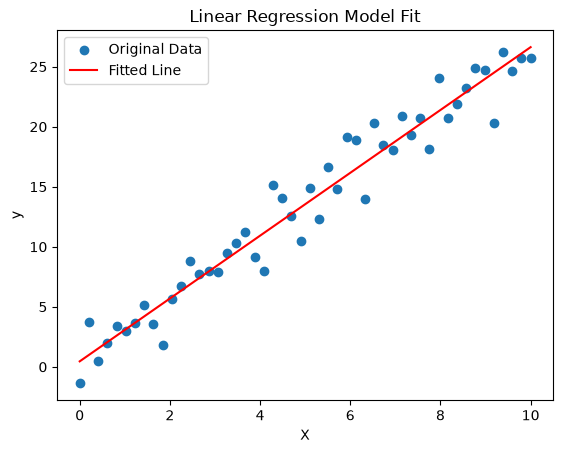

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

# =========================
# 1. GENERATE RANDOM DATA
# =========================
# generate data
X = np.linspace(0, 10, 50)
true_w = 2.5
true_b = 1.0

noise = np.random.randn(50) * 2
y = true_w * X + true_b + noise

X = X.reshape(-1, 1)
y = y.reshape(-1, 1)

# =========================
# 2. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 3. TRAIN MODEL
# =========================
model = LinearRegression()
model.fit(X_train, y_train)

# =========================
# 4. PREDICT
# =========================
y_pred = model.predict(X_test)

# =========================
# 5. METRICS
# =========================
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Slope (w):", model.coef_[0])
print("Intercept (b):", model.intercept_)

print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")

# =========================
# 6. PLOT
# =========================
# Plot the original full dataset
plt.scatter(X, y, label="Original Data")

# Generate predictions for the entire dataset (X) to plot the regression line over the full range
y_full_pred = model.predict(X)

# Sort X and its predictions to ensure the line is drawn correctly
sorted_indices = np.argsort(X.flatten())
X_sorted_full = X[sorted_indices]
y_full_pred_sorted = y_full_pred[sorted_indices]

# Plot the fitted line using predictions on the full dataset
plt.plot(X_sorted_full, y_full_pred_sorted, color='red', label="Fitted Line")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Model Fit")
plt.legend()
plt.show()

# Model Evaluation: Regression Metrics

A model evaluation metric is a numerical way to measure how good a machine learning model is at making predictions.

👉 In simple terms:

It tells you how **wrong** or **right** your model is.


![](https://miro.medium.com/1*5fnmYVHLTC8mGxybHm4XkA.png)

![](https://backend.aionlinecourse.com/uploads/tutorials/2019/05/29_1_Evaluating_Regression_Performance.jpg)


📉 MSE
penalizes big errors heavily
sensitive to outliers


📏 RMSE
same as MSE but in real units
more interpretable


📌 MAE
average absolute error
most intuitive (“off by ~X units”)


📊 R²
how good model is compared to baseline mean prediction


🔥 Quick intuition example

If:

- MAE = 2.5 → model is off by ~2.5 units on average
- RMSE = 3.8 → some big errors exist
- R² = 0.9 → very good fit

![](https://b3252691.smushcdn.com/3252691/wp-content/uploads/2026/02/ai_64-1536x864.png?lossy=2&strip=1&webp=1)


### Choosing the right metric


- **MAE**: When you care about absolute errors (robust to outliers).
- **MSE / RMSE**: When large errors are more serious (penalizes big mistakes).
- **R²**: When you want to measure overall **goodness of fit**.

✅ In practice:
- Use **MAE or RMSE** for error magnitude.
- Use **R²** for interpretability.
- Compare multiple metrics to make a decision.


## ✅ Simple 1-Feature Linear Regression + Plot

Let’s use **`RM` (average number of rooms)** since it has a strong relationship with house price.

---

## 🧠 Intuition (this is the important part)

* Each point = a house
* X-axis = number of rooms
* Y-axis = price

👉 The line:

```
Price = m * RM + c
```

* **m (slope)** → how much price increases per extra room
* **c (intercept)** → base price when RM = 0 (not realistic, but mathematically needed)

---

## 🔥 What you’ll observe

* Clear **positive relationship** (more rooms → higher price)
* Points won’t perfectly lie on the line → real-world noise
* R² will be decent but not perfect → because we’re ignoring other features



MAE: 4.4783
R2 : 0.3708
RMSE: 6.7930
MSE: 46.1448

Model Equation:
Price = 9.35 * RM + -36.25


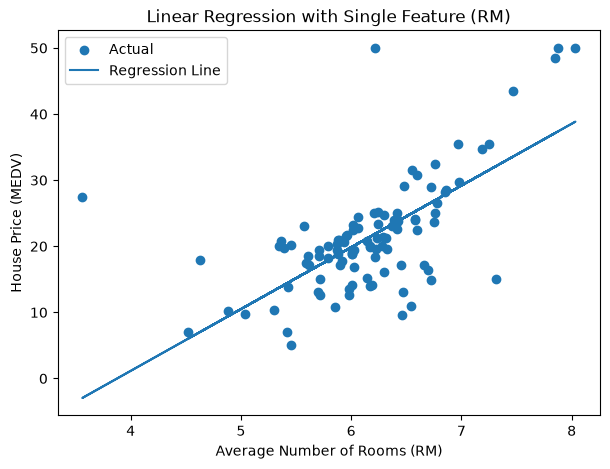

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, mean_squared_error

# Load dataset (fixed deprecation)
data_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/housing.data"

columns = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
    'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'
]

df = pd.read_csv(data_url, sep=r"\s+", names=columns)

# ----------------------------
# 1. Use SINGLE feature
# ----------------------------
X = df[['RM']]     # only one feature
y = df['MEDV']     # target

# ----------------------------
# 2. Train-Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------
# 3. Train Model
# ----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# ----------------------------
# 4. Predictions
# ----------------------------
y_pred = model.predict(X_test)

# ----------------------------
# 5. Evaluation
# ----------------------------
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"R2 : {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MSE: {mse:.4f}")

# ----------------------------
# 6. Line Equation
# ----------------------------
print(f"\nModel Equation:")
print(f"Price = {model.coef_[0]:.2f} * RM + {model.intercept_:.2f}")

# ----------------------------
# 7. Visualization
# ----------------------------
plt.figure(figsize=(7,5))

# scatter plot (actual data)
plt.scatter(X_test, y_test, label="Actual")

# regression line
plt.plot(X_test, y_pred, label="Regression Line")

plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("House Price (MEDV)")
plt.title("Linear Regression with Single Feature (RM)")
plt.legend()

plt.show()

## Using All Features in Linear Regression

When you use **all features** instead of just one:

### 🔹 Model changes from line → hyperplane

* Single feature:

  ```
  y = m x + c   → straight line
  or,
  y = wx + b
  ```
* Multiple features:

  ```
  y = w1x1 + w2x2 + ... + wnxn + b
  ```

👉 Now it’s no longer a 2D line — it becomes a **hyperplane in higher dimensions**

---

#### 🔹 Interpretation becomes harder

* With one feature (e.g., RM), you can clearly see:

  > “More rooms → higher price”
* With many features:

  * Each coefficient shows *partial impact*
  * But features interact → intuition is less visual

---

#### 🔹 Performance usually improves

* More features = more information
* Typically:

  * ↓ Error (MAE, MSE)
  * ↑ R² score

⚠️ But only if features are meaningful

---

#### 🔹 Risk of overfitting

* Too many features → model may memorize noise
* Especially if:

  * dataset is small
  * features are irrelevant

👉 Solution:

* Train/test split ✅
* Cross-validation ✅
* Regularization (Ridge/Lasso) ✅

---

#### 🔹 Feature scaling may matter

* LinearRegression itself doesn’t require scaling
* But scaling helps:

  * interpret coefficients
  * use regularized models

---

#### 🔹 Multicollinearity issue

* Some features may be highly correlated (e.g., TAX & RAD)
* This can:

  * distort coefficients
  * reduce interpretability

---

#### 🔹 Practical takeaway

* Start with **1 feature → build intuition**
* Then move to **all features → improve performance**
* Then refine with:

  * feature selection
  * regularization


Evaluation Metrics:
MAE  : 3.1891
MSE  : 24.2911
RMSE : 4.9286
R2   : 0.6688


Feature Coefficient(W/m):
    Feature  Coefficient
5        RM     4.438835
3      CHAS     2.784438
8       RAD     0.262430
2     INDUS     0.040381
1        ZN     0.030110
11        B     0.012351
6       AGE    -0.006296
9       TAX    -0.010647
0      CRIM    -0.113056
12    LSTAT    -0.508571
10  PTRATIO    -0.915456
7       DIS    -1.447865
4       NOX   -17.202633


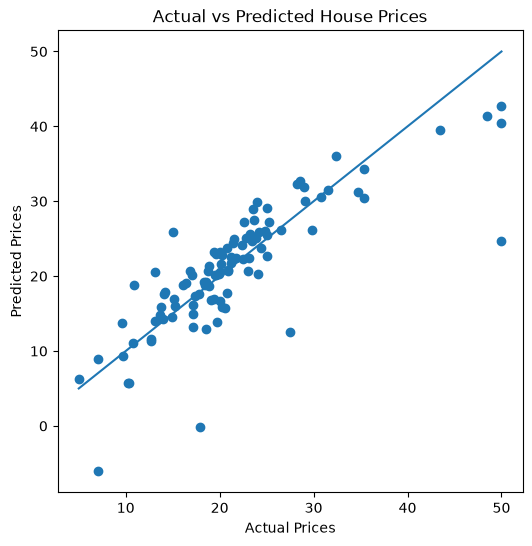

In [ ]:

# ----------------------------
# 1. Feature & Target Split
# ----------------------------
X = df.drop('MEDV', axis=1)   # features
y = df['MEDV']                # target

# ----------------------------
# 2. Train-Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------
# 3. Model Training
# ----------------------------
model = LinearRegression() # Ridge(), # Lasso()
model.fit(X_train, y_train)

# ----------------------------
# 4. Prediction
# ----------------------------
y_pred = model.predict(X_test)

# ----------------------------
# 5. Evaluation Metrics
# ----------------------------
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Evaluation Metrics:")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")
print()

# ----------------------------
# 6. Coefficients
# ----------------------------
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nFeature Coefficient(W/m):")
print(coeff_df.sort_values(by='Coefficient', ascending=False))

# ----------------------------
# 7. Visualization
# ----------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.plot([y.min(), y.max()], [y.min(), y.max()])  # diagonal line
plt.show()

Gradient Discent Explanation: In Progress

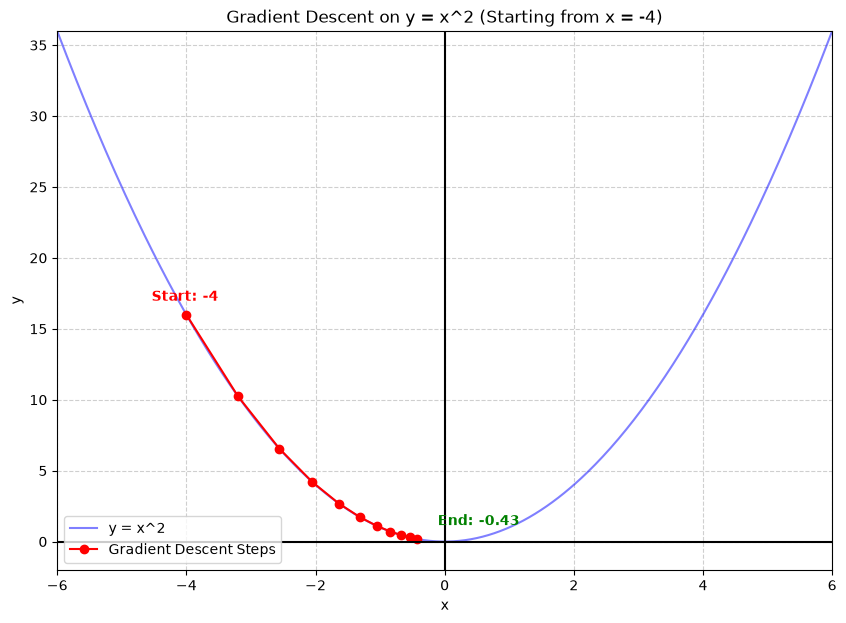

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the function and its derivative (gradient)
def f(x):
    return x**2

def df(x):
    return 2*x

# 2. Set Parameters
x_start = -4
learning_rate = 0.1
iterations = 10

# 3. Perform Gradient Descent
x_steps = [x_start]
y_steps = [f(x_start)]
x_curr = x_start

for _ in range(iterations):
    gradient = df(x_curr)
    x_curr = x_curr - (learning_rate * gradient)
    x_steps.append(x_curr)
    y_steps.append(f(x_curr))

# 4. Generate Plot
x_vals = np.linspace(-6, 6, 400)
y_vals = f(x_vals)

plt.figure(figsize=(10, 7))

# Plot the main curve
plt.plot(x_vals, y_vals, 'b-', label='y = x^2', alpha=0.5)

# Plot the descent path
plt.plot(x_steps, y_steps, 'ro-', label='Gradient Descent Steps', markersize=6)

# Setup 4-quadrant view
plt.axhline(0, color='black', linewidth=1.5) # X-axis
plt.axvline(0, color='black', linewidth=1.5) # Y-axis
plt.grid(True, linestyle='--', alpha=0.6)

# Annotations
plt.annotate(f'Start: {x_steps[0]}', (x_steps[0], y_steps[0]),
             textcoords="offset points", xytext=(-25,10), color='red', weight='bold')
plt.annotate(f'End: {x_steps[-1]:.2f}', (x_steps[-1], y_steps[-1]),
             textcoords="offset points", xytext=(15,10), color='green', weight='bold')

plt.title('Gradient Descent on y = x^2 (Starting from x = -4)')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-6, 6)
plt.ylim(-2, 36)
plt.legend()
plt.show()

![](https://ml-visualized.com/_images/37fc5f81b5fc7298773cbe3d28d0b69d41bfa59bae6e264c3c4377dc469eaf0b.gif)

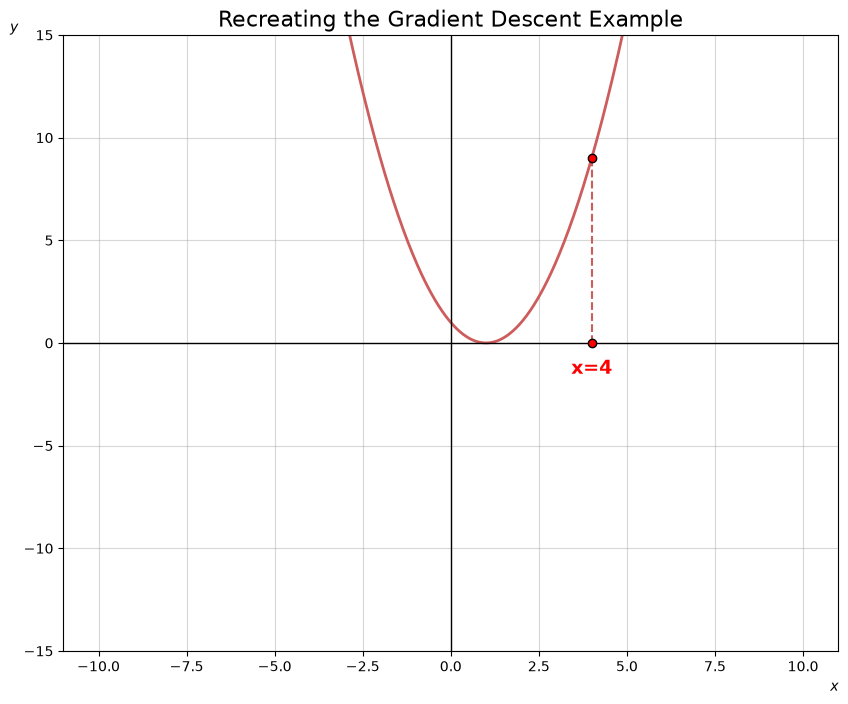

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the function
def f(x):
    return (x - 1)**2

# 2. Setup Data
x = np.linspace(-10, 10, 600)
y = f(x)
x_point = 4
y_point = f(x_point)

# 3. Create Plot
plt.figure(figsize=(10, 8))
plt.plot(x, y, color='indianred', linewidth=2)

# Point on the curve and on the x-axis
plt.scatter([x_point,  x_point], [y_point, 0], color='red', edgecolors='black', zorder=5)

# 4. Vertical dashed line (The 'pointer')
plt.vlines(x=x_point, ymin=0, ymax=y_point, colors='indianred', linestyles='dashed')

# 5. Labeling the x-value specifically in red
plt.text(x_point, -1.5, f'x={x_point}', color='red', fontsize=14, fontweight='bold', ha='center')

# 6. Formatting to match the image style
plt.axhline(0, color='black', linewidth=1) # X-axis
plt.axvline(0, color='black', linewidth=1) # Y-axis
plt.grid(True, which='both', linestyle='-', alpha=0.5)

# Set limits and labels
plt.xlim(-11, 11)
plt.ylim(-15, 15)
plt.xlabel('x', loc='right', fontstyle='italic')
plt.ylabel('y', loc='top', rotation=0, fontstyle='italic')

plt.title("Recreating the Gradient Descent Example", fontsize=16)
plt.show()

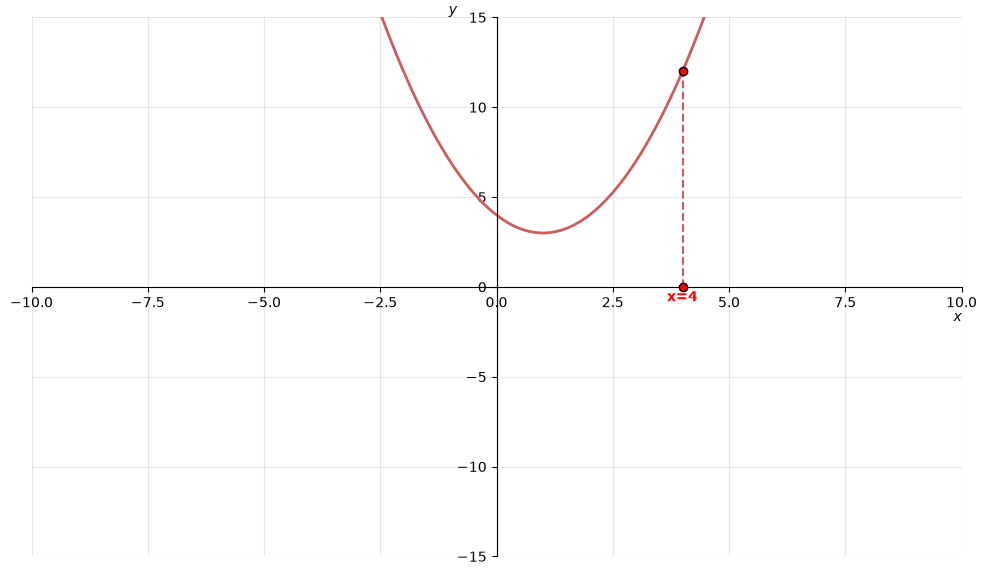

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the function (as seen in image_561f24.png)
def f(x):
    return (x-1)**2 + 3

# 2. Setup Data
x = np.linspace(-10, 10, 400)
y = f(x)
x_point = 4
y_point = f(x_point)

# 3. Create Plot
fig, ax = plt.subplots(figsize=(12,7))
ax.plot(x, y, color='indianred', linewidth=2)

# 4. Center the Spines (This moves ticks to the axis lines)
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')

# Hide the top and right spines
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# 5. Add specific markers and dashed guide line
ax.scatter([x_point, x_point], [y_point, 0], color='red', edgecolors='black', zorder=5)
ax.vlines(x=x_point, ymin=0, ymax=y_point, colors='indianred', linestyles='dashed')

# 6. Add the red x-label directly on the axis
ax.text(x_point, -0.8, f'x={x_point}', color='red', fontsize=10, fontweight='bold', ha='center')

# 7. Final Formatting
ax.grid(True, linestyle='-', alpha=0.3)
ax.set_xlim(-10, 10)
ax.set_ylim(-15, 15)

# Labeling the actual axes
ax.set_xlabel('x', loc='right', fontstyle='italic', labelpad=0)
ax.set_ylabel('y', loc='top', rotation=0, fontstyle='italic', labelpad=0)

plt.show()

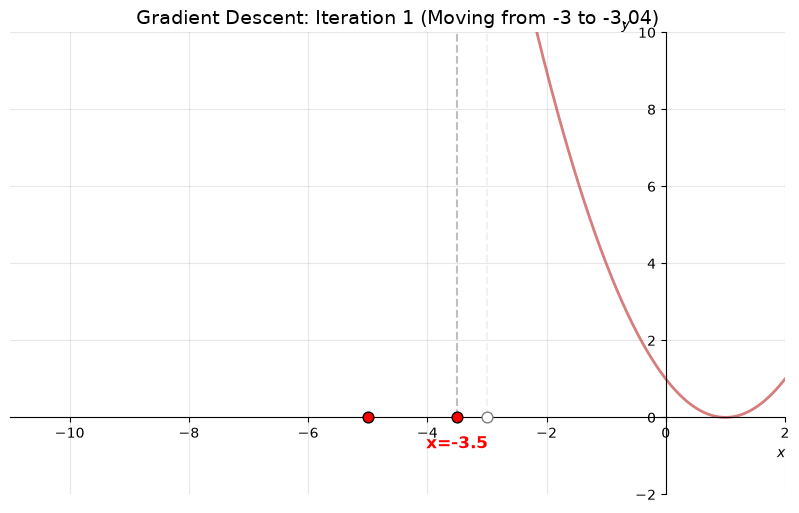

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Function and Parameters
def f(x):
    return (x - 1)**2

x_prev = -3.0
x_curr = -3.5  # Result from Iteration 1 in the image
y_prev = f(x_prev)
y_curr = f(x_curr)

# 2. Generate Curve Data
x_range = np.linspace(-10, 2, 400)
y_range = f(x_range)

# 3. Create Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_range, y_range, color='indianred', linewidth=2, alpha=0.8)

# 4. Center Axis Spines
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# 5. Plot Points
# Previous Point: White with gray edge
ax.scatter([x_prev, x_prev], [y_prev, 0], color='white', edgecolors='gray', s=60, zorder=5, label='Previous')
# Current Point: Red
ax.scatter([x_curr, x_curr, -5], [y_curr, 0, 0], color='red', edgecolors='black', s=60, zorder=6, label='Current')

# 6. Add Guide Lines and Arrow
# Dashed lines for current x
ax.vlines(x=x_curr, ymin=0, ymax=y_curr, colors='gray', linestyles='dashed', alpha=0.5)
ax.vlines(x=x_prev, ymin=0, ymax=y_prev, colors='lightgray', linestyles='dashed', alpha=0.3)

# Red Directional Arrow
ax.annotate('', xy=(x_curr - 0.1, y_curr + 0.5), xytext=(x_prev - 0.1, y_prev + 0.5),
             arrowprops=dict(arrowstyle='->', color='red', lw=2))

# 7. Labels and Formatting
ax.text(x_curr, -0.8, f'x={x_curr}', color='red', fontsize=12, fontweight='bold', ha='center')
ax.set_xlim(-11, 2)
ax.set_ylim(-2, 10)
ax.grid(True, linestyle='-', alpha=0.3)

# Axis labels
ax.set_xlabel('x', loc='right', fontstyle='italic')
ax.set_ylabel('y', loc='top', rotation=0, fontstyle='italic')

plt.title("Gradient Descent: Iteration 1 (Moving from -3 to -3.04)", fontsize=14)
plt.show()

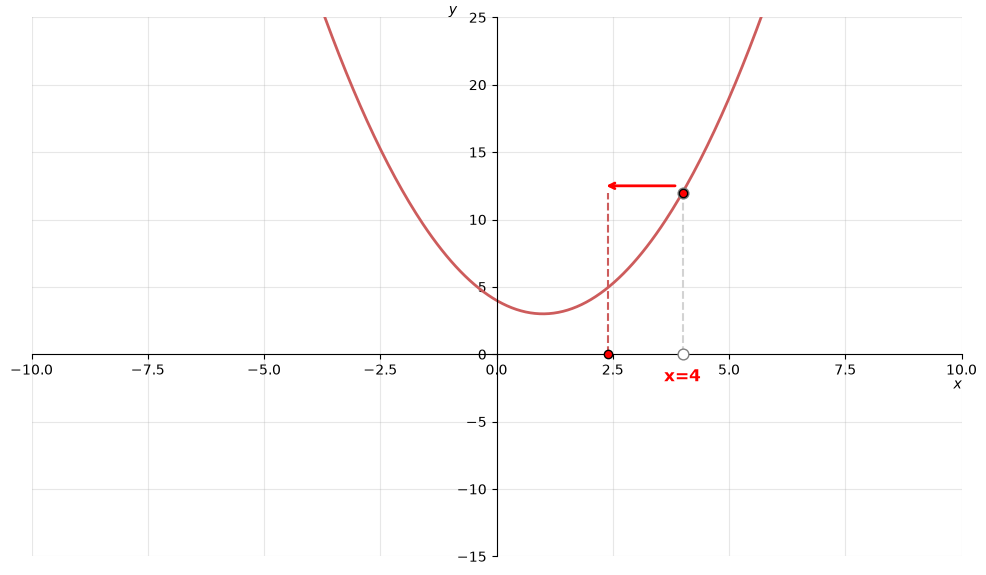

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the function (as seen in image_561f24.png)
def f(x):
    return (x-1)**2 + 3

# 2. Setup Data
x = np.linspace(-10, 10, 400)
y = f(x)

x_curr = 2.4
y_curr = f(x_point)

x_prev = 4
y_prev = f(x_prev)


# 3. Create Plot
fig, ax = plt.subplots(figsize=(12,7))
ax.plot(x, y, color='indianred', linewidth=2)

# 4. Center the Spines (This moves ticks to the axis lines)
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')

# Hide the top and right spines
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# 5. Add specific markers and dashed guide line
# Previous Point: White with gray edge
ax.scatter([x_prev, x_prev], [y_prev, 0], color='white', edgecolors='gray', s=60, zorder=5, label='Previous')
ax.vlines(x=x_prev, ymin=0, ymax=y_prev, colors='lightgray', linestyles='dashed')
# Current Point: Red with black edge
ax.scatter([x_point, x_curr], [y_curr, 0], color='red', edgecolors='black', zorder=5)
ax.vlines(x=x_curr, ymin=0, ymax=y_curr, colors='indianred', linestyles='dashed')

# Red Directional Arrow
ax.annotate('', xy=(x_curr - 0.1, y_curr + 0.5), xytext=(x_prev - 0.1, y_prev + 0.5),
             arrowprops=dict(arrowstyle='->', color='red', lw=2))


# 6. Add the red x-label directly on the axis
ax.text(x_point, -2, f'x={x_point}', color='red', fontsize=12, fontweight='bold', ha='center')

# 7. Final Formatting
ax.grid(True, linestyle='-', alpha=0.3)
ax.set_xlim(-10, 10)
ax.set_ylim(-15, 25)

# Labeling the actual axes
ax.set_xlabel('x', loc='right', fontstyle='italic', labelpad=0)
ax.set_ylabel('y', loc='top', rotation=0, fontstyle='italic', labelpad=0)

plt.show()

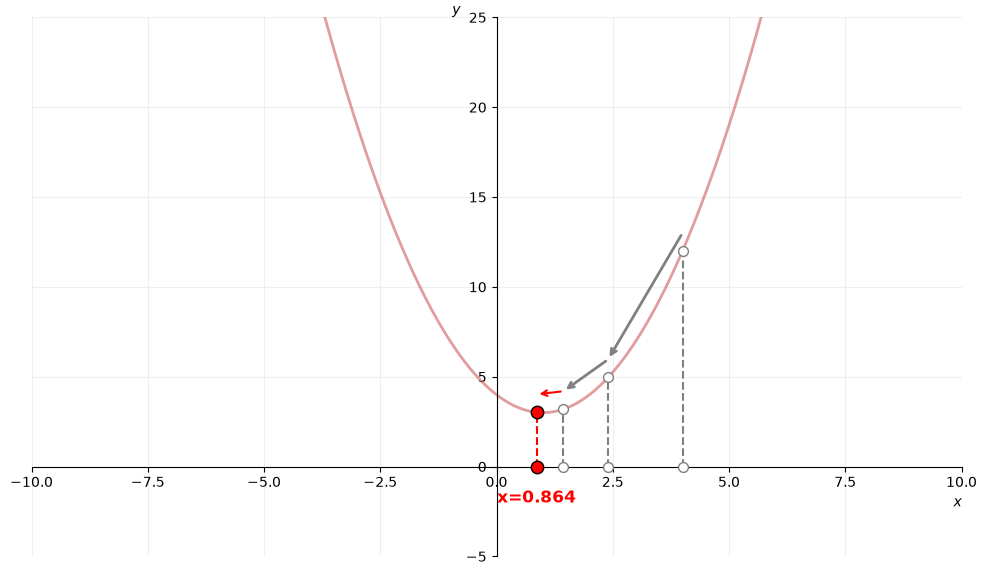

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the function
def f(x):
    return (x - 1)**2 + 3

# 2. Setup Data
x_range = np.linspace(-10, 10, 400)
y_vals = f(x_range)

# List of previous points (the "history")
x_history = [4, 2.4, 1.44]
# The current focal point
x_curr = 0.864
y_curr = f(x_curr)

# 3. Create Plot
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(x_range, y_vals, color='indianred', linewidth=2, alpha=0.6)

# 4. Center the Spines
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

# 5. Add Multiple Previous Points from the list
for i, x_prev in enumerate(x_history):
    y_prev = f(x_prev)
    # Plot white points with decreasing transparency (older points are lighter)
    # alpha_val = (i + 1) / len(x_history) * 0.5
    alpha_val = 1
    ax.scatter([x_prev, x_prev], [y_prev, 0], color='white', edgecolors='gray', s=50, zorder=4, alpha=alpha_val)
    ax.vlines(x=x_prev, ymin=0, ymax=y_prev, colors='gray', linestyles='dashed', alpha=alpha_val)

    # Optional: Add arrow from this point to the next one in history
    if i < len(x_history) - 1:
        next_x = x_history[i+1]
        ax.annotate('', xy=(next_x, f(next_x) + 1), xytext=(x_prev, y_prev + 1),
                     arrowprops=dict(arrowstyle='->', color='gray', lw=2, alpha=alpha_val))

# 6. Add Current Point (Red)
ax.scatter([x_curr, x_curr], [y_curr, 0], color='red', edgecolors='black', s=80, zorder=6)
ax.vlines(x=x_curr, ymin=0, ymax=y_curr, colors='red', linestyles='dashed', lw=1.5)

# Arrow from last history point to current point
last_x_prev = x_history[-1]
ax.annotate('', xy=(x_curr, f(x_curr) + 1), xytext=(last_x_prev, f(last_x_prev) + 1),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

# 7. Labels and Formatting
ax.text(x_curr, -2, f'x={x_curr}', color='red', fontsize=12, fontweight='bold', ha='center')
ax.grid(True, linestyle='-', alpha=0.2)
ax.set_xlim(-10, 10)
ax.set_ylim(-5, 25)

ax.set_xlabel('x', loc='right', fontstyle='italic')
ax.set_ylabel('y', loc='top', rotation=0, fontstyle='italic')

# plt.title("Gradient Descent: Visualizing History with Multiple Steps")
plt.show()